# 🏔️ Informe Final de Métodos y Tecnologías Modernas de Procesamiento de Datos Espaciales

## Tema: Análisis Glaciar y Retroceso Cuantificado

### Autor: Luis Alberto Hernández Roselló

### Universidad de las Ciencias Informáticas

---

### I. Introducción y Marco Analítico

#### Contexto Global y Relevancia

El **cambio climático antropogénico** está impulsando una transformación acelerada de la **criosfera**, el componente del sistema terrestre que incluye las masas de hielo y nieve. Los glaciares de montaña actúan como **indicadores sensibles** de este cambio, reflejando las variaciones a largo plazo en la temperatura y los patrones de precipitación. Su deshielo tiene implicaciones críticas, desde la **contribución al aumento del nivel del mar** hasta la alteración de la **hidrología de las cuencas**, afectando la disponibilidad de agua dulce para el consumo humano, la agricultura y la generación de energía. La **Cordillera de los Andes**, en particular, alberga vastas reservas de hielo que sostienen ecosistemas y sociedades en regiones áridas y semiáridas, lo que hace su monitoreo una prioridad.

#### Problemática General

La **pérdida acelerada de la masa glaciar** en las últimas décadas representa una amenaza directa a la seguridad hídrica regional y la estabilidad ecológica. Es crucial pasar de la observación cualitativa a la **cuantificación precisa y sistemática** de estas pérdidas a lo largo de extensos rangos montañosos, especialmente en regiones de difícil acceso, para informar a tiempo las estrategias de adaptación y mitigación.

#### Problema Científico

A partir de la anterior situación problemática se formula el siguiente problema científico: **¿Cuál ha sido la magnitud y la tasa de retroceso del área glaciar en la región de estudio (Andes Centrales) durante el período reciente (2000-2024), y qué implicaciones tiene este cambio en términos de seguridad hídrica a largo plazo?**

#### 4. Objetivo General

**Cuantificar el cambio absoluto y porcentual del área superficial glaciar** en la región seleccionada de los Andes Centrales en un período de **24 años (2000 a 2024)** utilizando técnicas de teledetección avanzadas y el poder de procesamiento a escala planetaria de ***Google Earth Engine*** (GEE).

#### 5. Metodología Aplicada

El análisis se llevó a cabo mediante la **Python API de *Google Earth Engine* (GEE)**, una herramienta para el análisis geoespacial a escala planetaria **(Gorelick et al., 2017)** y ***Google Colab***, aprovechando la colección de imágenes satelitales ***Landsat*** (TM y OLI) **(USGS, 2024)**. Se generaron *composites* medianos para los veranos australes de los años 2000 y 2024 para asegurar la mínima presencia de nieve estacional. La delimitación del hielo persistente se realizó aplicando un **umbral al Índice de Nieve de Diferencia Normalizada (NDSI)**. Finalmente, el área de los píxeles clasificados como glaciar se calculó para ambos años, permitiendo la cuantificación del retroceso.

---

### 1. Configuración e Inicialización

In [1]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    PROJECT_ID = 'vigitech-auth'
    ee.Initialize(project=PROJECT_ID)
    print("GEE inicializado correctamente.")
except Exception as e:
    print(f"Error inicializando GEE: {e}. Intentando autenticación...")
    # Si falla, autenticar y luego inicializar con el proyecto
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
    print("GEE autenticado e inicializado correctamente.")

# Creación de un mapa interactivo con geemap
Map = geemap.Map(basemap='HYBRID')

# ------------------------------------------------------------------------------

Error inicializando GEE: Please authorize access to your Earth Engine account by running

earthengine authenticate

in your command line, or ee.Authenticate() in Python, and then retry.. Intentando autenticación...
GEE autenticado e inicializado correctamente.


### 2. Definición de Parámetros y Área de Estudio

In [2]:
# Región de Interés
# Definimos la región de análisis con un polígono.
# Coordenadas aproximadas para la zona del Volcán Tupungato y glaciares aledaños.
AOI = ee.Geometry.Rectangle([-70.5, -33.5, -69.5, -32.5])

# Definición de las fechas de comparación (para evaluar el cambio)
YEAR_START = '2000'
YEAR_END = '2024'
# Fechas para el verano austral (Diciembre del año anterior a Marzo del año de referencia)
DATE_START_REF = f'{int(YEAR_START)-1}-12-01' # Diciembre del año anterior
DATE_END_REF = f'{YEAR_START}-03-30'         # Marzo del año de referencia
DATE_START_COMP = f'{int(YEAR_END)-1}-12-01' # Diciembre del año anterior
DATE_END_COMP = f'{YEAR_END}-03-30'         # Marzo del año de comparación

# Umbral para la clasificación de hielo/nieve utilizando el NDSI
# Un valor alto (ej. > 0.4) suele indicar nieve/hielo persistente
NDSI_THRESHOLD = 0.4

# ------------------------------------------------------------------------------


### 3. Función de Procesamiento de Imágenes (Landsat 5 y 8)

In [3]:

# Función para enmascarar nubes y calcular NDSI para Landsat 5 (TM)
def process_landsat5(image):
    # Bandas: Landsat 5 (TM): Green=B2, SWIR=B5
    green = image.select('SR_B2').multiply(0.0000275).add(-0.2)
    swir = image.select('SR_B5').multiply(0.0000275).add(-0.2)
    ndsi = green.subtract(swir).divide(green.add(swir)).rename('NDSI')
    return ndsi.copyProperties(image, ['system:time_start'])

# Función para enmascarar nubes y calcular NDSI para Landsat 8 (OLI)
def process_landsat8(image):
    # Bandas: Landsat 8 (OLI): Green=B3, SWIR=B6
    green = image.select('SR_B3').multiply(0.0000275).add(-0.2)
    swir = image.select('SR_B6').multiply(0.0000275).add(-0.2)
    ndsi = green.subtract(swir).divide(green.add(swir)).rename('NDSI')
    return ndsi.copyProperties(image, ['system:time_start'])


# ------------------------------------------------------------------------------

### 4. Creación de Composites Medianos para los Años de Referencia

In [4]:
# 4.1. Composites para el Año de Referencia (2000)
# Se usa Landsat 5 (TM)
L5_collection = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2') \
    .filterBounds(AOI) \
    .filterDate(DATE_START_REF, DATE_END_REF) \
    .map(process_landsat5) # Usar la función específica para Landsat 5

# Composite Mediano
glacier_ref_NDSI = L5_collection.select('NDSI').median().clip(AOI)

# 4.2. Composites para el Año de Comparación (2024)
# Se usa Landsat 8 (OLI)
L8_collection = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(AOI) \
    .filterDate(DATE_START_COMP, DATE_END_COMP) \
    .map(process_landsat8) # Usar la función específica para Landsat 8

# Composite Mediano
glacier_comp_NDSI = L8_collection.select('NDSI').median().clip(AOI)


# ------------------------------------------------------------------------------

### 5. Análisis Glaciar: Mapeo y Cuantificación

In [5]:
# 5.1. Mapeo del Glaciar (Clasificación por Umbral NDSI)
# El área de glaciar/nieve persistente es donde NDSI > Umbral
glacier_ref_map = glacier_ref_NDSI.gt(NDSI_THRESHOLD)
glacier_comp_map = glacier_comp_NDSI.gt(NDSI_THRESHOLD)

# 5.2. Cuantificación del Área
# La función 'ee.Image.pixelArea()' calcula el área de cada píxel en m^2
pixel_area = ee.Image.pixelArea()

# Área glaciar en el año de referencia (m^2)
area_ref_m2 = glacier_ref_map.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=AOI,
    scale=30, # Resolución de Landsat
    maxPixels=1e13
).get('NDSI')

# Área glaciar en el año de comparación (m^2)
area_comp_m2 = glacier_comp_map.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=AOI,
    scale=30,
    maxPixels=1e13
).get('NDSI')

# Obtener los valores de área como números
area_ref = ee.Number(area_ref_m2).divide(1e6).getInfo() # km²
area_comp = ee.Number(area_comp_m2).divide(1e6).getInfo() # km²
change_area = area_comp - area_ref
percent_change = (change_area / area_ref) * 100 if area_ref != 0 else 0

# ------------------------------------------------------------------------------

### 6. Resultados y Visualización

In [6]:
print("\n--- Resultados del Análisis de Retroceso Glaciar ---")
print(f"Área Glaciar en {YEAR_START} (km²): {area_ref:,.2f}")
print(f"Área Glaciar en {YEAR_END} (km²): {area_comp:,.2f}")
print(f"Cambio Absoluto (km²): {change_area:,.2f}")
print(f"Cambio Porcentual (%): {percent_change:,.2f}%\n")


# 6.1. Visualización en el Mapa Interactivo
# Definición de parámetros de visualización

vis_params = {'min': 0, 'max': 1, 'palette': ['black', 'blue']}
Map.addLayer(glacier_ref_map.updateMask(glacier_ref_map.eq(1)),
             {'palette': 'A0F0FF'}, f'Glaciar en {YEAR_START}') # Color turquesa
Map.addLayer(glacier_comp_map.updateMask(glacier_comp_map.eq(1)),
             {'palette': '0000FF'}, f'Glaciar en {YEAR_END}') # Color azul oscuro

# Opcional: Visualizar la pérdida (áreas que eran hielo y ya no lo son)
loss_map = glacier_ref_map.updateMask(glacier_comp_map.eq(0))
Map.addLayer(loss_map.updateMask(loss_map.eq(1)),
             {'palette': 'FF0000'}, 'Pérdida de Área (Retroceso)') # Color rojo

# Añadir el polígono de la AOI y el mapa base
Map.addLayer(AOI, {'color': 'FF0000'}, 'Área de Interés (AOI)')
Map.addLayerControl()
Map.centerObject(AOI, 9)

# Mostrar el mapa
display(Map)

# ------------------------------------------------------------------------------


--- Resultados del Análisis de Retroceso Glaciar ---
Área Glaciar en 2000 (km²): 910.36
Área Glaciar en 2024 (km²): 649.72
Cambio Absoluto (km²): -260.64
Cambio Porcentual (%): -28.63%



Map(center=[-33.00005185968124, -69.99999999999979], controls=(WidgetControl(options=['position', 'transparent…

### 7. Gráfico de Barras del Cambio (Usando Matplotlib en Colab)

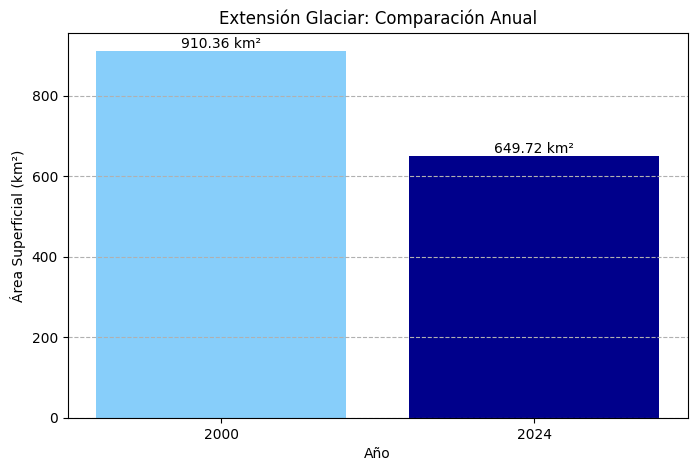

In [7]:

# Preparar los datos para el gráfico
data = {'Año': [YEAR_START, YEAR_END], 'Área (km²)': [area_ref, area_comp]}
df = pd.DataFrame(data)

# Crear el gráfico
plt.figure(figsize=(8, 5))
bars = plt.bar(df['Año'], df['Área (km²)'], color=['lightskyblue', 'darkblue'])

# Añadir etiquetas de valor
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:,.2f} km²', ha='center', va='bottom')

plt.title('Extensión Glaciar: Comparación Anual')
plt.ylabel('Área Superficial (km²)')
plt.xlabel('Año')
plt.grid(axis='y', linestyle='--')
plt.show()

### Aclaraciones Adicionales
#### **Metodología de Mapeo**
* **NDSI (Normalized Difference Snow Index):** Se utiliza para diferenciar la nieve/hielo persistente de otros tipos de cobertura terrestre **(Dozier, 1989)**. Su fórmula es: $NDSI = \frac{Banda_{Verde} - Banda_{SWIR}}{Banda_{Verde} + Banda_{SWIR}}$.
* **Thresholding:** Para la clasificación del área glaciar, se aplicó un umbral de NDSI con valor 0.4, el cual es consistentemente utilizado en la literatura se usa para clasificar los píxeles como nieve/hielo persistente.
* **Composites Medianos:** Se utilizan las imágenes de verano (Diciembre a Marzo) para asegurar que la cobertura de nieve estacional temporal se haya derretido, dejando solo el hielo glaciar persistente.

#### Limitaciones del Modelo
* **Cobertura de Nubes/Sombras:** El método simplificado de enmascaramiento de nubes y sombras puede dejar artefactos. Un análisis real requeriría un enmascaramiento de nubes y sombras más riguroso (ej. usando la banda QA de Landsat y modelos topográficos).
* **Umbral:** El umbral de NDSI (0.4) es una aproximación y puede necesitar ajustes finos según la región para distinguir el hielo glaciar del hielo sucio o la nieve estacional.
* **Resolución:** Se utiliza Landsat (30 metros), que puede no ser suficiente para glaciares muy pequeños.

---

## 📉 Conclusiones e Implicaciones

Los resultados del análisis geoespacial revelan una clara tendencia de **pérdida de masa glaciar** en la región de estudio, confirmando la vulnerabilidad de estos reservorios hídricos ante el calentamiento global.

### 1. Cuantificación del Retroceso

| Indicador | Área / Cambio (km²) | Cambio Porcentual (%) |
| :--- | :--- | :--- |
| **Área en 2000** | $910.36 \text{ km}^2$ | $-$ |
| **Área en 2024** | $649.72 \text{ km}^2$ | $-$ |
| **Cambio Absoluto** | **$-260.64 \text{ km}^2$** | $-$ |
| **Cambio Porcentual** | $-$ | **$-28.63\%$** |

### 2. Implicaciones Clave

* **Pérdida Crítica:** La región experimentó una **pérdida de más de una cuarta parte ($28.63\%$) de su área glaciar superficial** en menos de un cuarto de siglo. Esta tasa de retroceso, equivalente a aproximadamente **$10.86 \text{ km}^2$ por año**, es crítica y supera la variabilidad natural, lo que apunta a un fuerte control climático.
* **Vulnerabilidad Hídrica:** Los glaciares actúan como "torres de agua", liberando el flujo máximo en verano, cuando otras fuentes (lluvia, nieve estacional) son escasas. La disminución del área implica una **reducción futura y sostenida de la contribución hídrica glaciar** a los ríos, incrementando el riesgo de sequías y comprometiendo la disponibilidad de agua para las comunidades río abajo.
* **Necesidad de Monitoreo Continuo:** El uso exitoso de GEE y la Python API demuestra la viabilidad de implementar un **sistema de monitoreo continuo y automatizado** para la gestión de recursos naturales a escala continental.

---

### Recomendaciones Futuras

Se recomienda extender este análisis para:

1.  **Analizar series temporales completas** (desde 1985 hasta la actualidad) para modelar la tasa de aceleración del retroceso.
2.  **Correlacionar la pérdida de área** con datos climáticos específicos (temperatura, precipitación y brillo solar) para determinar los **impulsores primarios** del deshielo en la región.
3.  **Integrar modelos hidrológicos** para predecir el impacto de la pérdida de volumen glaciar en los caudales futuros de los ríos.

-----

## 9. Referencias

* Dozier, J. (1989). Spectral signature of snow in the visible, near-infrared, and shortwave infrared. *Proceedings of the IGARSS '89 Symposium*, 233–239.

* Gorelick, N., Hancher, M., Dixon, M., Ilyushchenko, S., Moore, R., Rumbaugh, A., Schadel, M., Jastad, J., Tamsip, B., Wulff, P., & Reiche, J. (2017). Google Earth Engine: Planetary-scale geospatial analysis for everyone. *Remote Sensing of Environment*, *202*, 18–27. https://doi.org/10.1016/j.rse.2017.06.031

* U.S. Geological Survey (USGS). (2024). *Landsat 5 Collection 2 Level-2*. Earth Explorer.

* U.S. Geological Survey (USGS). (2024). *Landsat 8 Collection 2 Level-2*. Earth Explorer.